# Assignment 4

Deadline: 13.05.2026, 12:00 CET

<Add your name, student-id and emal address>

In [1]:
# Standard library imports
import os
import sys

# Third party imports
import numpy as np
import pandas as pd
import statsmodels.api as sm    # for regression analysis in 1.c) (or any other regression library you prefer)

# Add the project root directory to Python path
project_root = os.path.dirname(os.path.dirname(os.getcwd()))  # Change this path if needed
src_path = os.path.join(project_root, 'qpmwp-course\\src')
sys.path.append(project_root)
sys.path.append(src_path)

# Local modules imports
from helper_functions import (
    load_pickle,
    load_data_spi,
    align_market_data_with_jkp_data,
)
from estimation.covariance import Covariance
from optimization.optimization import PercentilePortfolio
from backtesting.backtest_item_builder.bib_classes import (
    SelectionItemBuilder,
    OptimizationItemBuilder,
)
from backtesting.backtest_item_builder.bibfn_selection import (
    bibfn_selection_gaps,
    bibfn_selection_min_volume,
    bibfn_selection_jkp_data_scores,
)
from backtesting.backtest_item_builder.bibfn_optimization_data import (
    bibfn_scores,
)
from backtesting.backtest_data import BacktestData
from backtesting.backtest_service import BacktestService
from backtesting.backtest import Backtest

c:\Users\marce\Desktop\qpmwp-course\src\optimization\optimization.py:39: SyntaxWarning: invalid escape sequence '\l'
  risk-adjusted returns ($\lambda \cdot x^T \Sigma x - \mu^T x$).
c:\Users\marce\Desktop\qpmwp-course\src\estimation\black_litterman.py:43: SyntaxWarning: invalid escape sequence '\S'
  Prior covariance matrix \\( \Sigma_{\text{prior}} \\).


## Constants

In [2]:
PATH_TO_DATA = r'C:/Users/marce/Desktop/qpmwp-course/data/'
SAVE_PATH = r'C:/Users/marce/Desktop/qpmwp-course/data/'

## Load data and initialize BacktestData class
- market data (from parquet file)
- jkp data (from parquet file)
- swiss performance index, SPI (from csv file)

In [3]:
# Load market and jkp data from parquet files
market_data = pd.read_parquet(path=f'{PATH_TO_DATA}market_data.parquet')
jkp_data = pd.read_parquet(path=f'{PATH_TO_DATA}jkp_data.parquet')
spi = load_data_spi(path=PATH_TO_DATA)

# Align market data with jkp data
market_data_ffill, jkp_data = align_market_data_with_jkp_data(
    market_data=market_data,
    jkp_data=jkp_data,
)

# Instantiate the BacktestData class
# and set the market, jkp, and benchmark data as attributes
data = BacktestData()
data.market_data = market_data_ffill
data.jkp_data = jkp_data
data.bm_series = spi

## Define a grid or rebalancing dates

In [4]:
n_month = 3 # We want to rebalance every n_month months
jkp_data_dates = (
    jkp_data
    .index.get_level_values('date')
    .unique().sort_values()
)
rebdates = (
    jkp_data_dates[
        jkp_data_dates > market_data.index.get_level_values('date').min()
    ][::n_month]
    .strftime('%Y-%m-%d').tolist()
)
rebdates = [date for date in rebdates if date > '2002-01-01']
rebdates

['2002-01-31',
 '2002-04-30',
 '2002-07-31',
 '2002-10-31',
 '2003-01-31',
 '2003-04-30',
 '2003-07-31',
 '2003-10-31',
 '2004-01-31',
 '2004-04-30',
 '2004-07-31',
 '2004-10-31',
 '2005-01-31',
 '2005-04-30',
 '2005-07-31',
 '2005-10-31',
 '2006-01-31',
 '2006-04-30',
 '2006-07-31',
 '2006-10-31',
 '2007-01-31',
 '2007-04-30',
 '2007-07-31',
 '2007-10-31',
 '2008-01-31',
 '2008-04-30',
 '2008-07-31',
 '2008-10-31',
 '2009-01-31',
 '2009-04-30',
 '2009-07-31',
 '2009-10-31',
 '2010-01-31',
 '2010-04-30',
 '2010-07-31',
 '2010-10-31',
 '2011-01-31',
 '2011-04-30',
 '2011-07-31',
 '2011-10-31',
 '2012-01-31',
 '2012-04-30',
 '2012-07-31',
 '2012-10-31',
 '2013-01-31',
 '2013-04-30',
 '2013-07-31',
 '2013-10-31',
 '2014-01-31',
 '2014-04-30',
 '2014-07-31',
 '2014-10-31',
 '2015-01-31',
 '2015-04-30',
 '2015-07-31',
 '2015-10-31',
 '2016-01-31',
 '2016-04-30',
 '2016-07-31',
 '2016-10-31',
 '2017-01-31',
 '2017-04-30',
 '2017-07-31',
 '2017-10-31',
 '2018-01-31',
 '2018-04-30',
 '2018-07-

## 1. a) Define the key data fields that characterize a factor theme

- Beside the pre-defined fields, choose three factor themes from table 9 of the Global Factor Data Documentation (See https://jkpfactors-data.s3.amazonaws.com/documents/Documentation.pdf, Section 10.) and add the individual fields.

**(2 points)**

In [5]:
print(jkp_data.columns.tolist())

['niq_su', 'ret_6_1', 'ret_12_1', 'saleq_su', 'tax_gr1a', 'ni_inc8q', 'prc_highprc_252d', 'resff3_6_1', 'resff3_12_1', 'be_me', 'debt_me', 'at_me', 'ret_60_12', 'ni_me', 'fcf_me', 'div12m_me', 'eqpo_me', 'eqnpo_me', 'sale_gr3', 'sale_gr1', 'ebitda_mev', 'sale_me', 'ocf_me', 'ival_me', 'bev_mev', 'netdebt_me', 'eq_dur', 'capex_abn', 'at_gr1', 'ppeinv_gr1a', 'noa_at', 'noa_gr1a', 'lnoa_gr1a', 'capx_gr1', 'capx_gr2', 'capx_gr3', 'chcsho_12m', 'eqnpo_12m', 'debt_gr3', 'inv_gr1', 'inv_gr1a', 'oaccruals_at', 'taccruals_at', 'cowc_gr1a', 'coa_gr1a', 'col_gr1a', 'nncoa_gr1a', 'ncoa_gr1a', 'ncol_gr1a', 'nfna_gr1a', 'sti_gr1a', 'lti_gr1a', 'fnl_gr1a', 'be_gr1a', 'oaccruals_ni', 'taccruals_ni', 'netis_at', 'eqnetis_at', 'dbnetis_at', 'niq_be', 'niq_be_chg1', 'niq_at', 'niq_at_chg1', 'ebit_bev', 'ebit_sale', 'sale_bev', 'at_turnover', 'gp_at', 'gp_atl1', 'ope_be', 'ope_bel1', 'op_at', 'op_atl1', 'cop_at', 'cop_atl1', 'f_score', 'o_score', 'z_score', 'pi_nix', 'at_be', 'saleq_gr1', 'rd_me', 'rd_sal

In [6]:
JKP_FIELDS_QUALITY = [
    'at_turnover',
    'cop_at',
    'cop_atl1',
    'dgp_dsale',
    'gp_at',
    'gp_atl1',
    'mispricing_perf',
    'ni_inc8q',
    'niq_at',
    'op_at',
    'op_atl1',
    'opex_at',
    'qmj_prof',
    'qmj_growth',
    'qmj_safety',
    'sale_bev',
]

JKP_FIELDS_VALUE = [
    'at_me',
    'be_me',
    'bev_mev',
    'debt_me',
    'div12m_me',
    'ebitda_mev',
    'eq_dur',
    'eqnetis_at',
    'eqnpo_12m',
    'eqnpo_me',
    'fcf_me',
    'ival_me',
    'netis_at',
    'ni_me',
    'ocf_me',
    'sale_me',
]

JKP_FIELDS_MOMENTUM = [
    'prc_highprc_252d',
    'resff3_6_1',
    'resff3_12_1',
    'ret_3_1',
    'ret_6_1',
    'ret_9_1',
    'ret_12_1',
    'seas_1_1na',
]

# Investment
JKP_FIELDS_THEME_1 = [
    'at_gr1',
    'ppeinv_gr1a',
    'noa_gr1a',
    'lnoa_gr1a',
    'capx_gr1',
    'capx_gr2',
    'capx_gr3',
    'inv_gr1',
    'inv_gr1a',
    'coa_gr1a',
    'col_gr1a',
    'nfna_gr1a',
    'fnl_gr1a',
]

# Profitability
JKP_FIELDS_THEME_2 = [
    'ni_be',
    'niq_be',
    'niq_at',
    'ebit_bev',
    'ebit_sale',
    'sale_bev',
    'gp_at',
    'gp_atl1',
    'op_at',
    'op_atl1',
    'cop_at',
    'cop_atl1',
    'f_score',
]

# Low risk
JKP_FIELDS_THEME_3 = [
    'ivol_ff3_21d',
    'ivol_capm_252d',
    'ivol_capm_21d',
    'rvol_21d',
    'beta_60m',
    'betabab_1260d',
    'beta_dimson_21d',
    'corr_1260d',
    'rmax1_21d',
    'rmax5_21d',
    'betadown_252d',
]


JKP_FIELDS = {
    'quality': JKP_FIELDS_QUALITY,
    'value': JKP_FIELDS_VALUE,
    'momentum': JKP_FIELDS_MOMENTUM,
    'investment': JKP_FIELDS_THEME_1,
    'profitability': JKP_FIELDS_THEME_2,
    'low_risk': JKP_FIELDS_THEME_3,
}

## 1. b) Factor series for each factor theme.

- For each factor theme, run a backtest for the top‑quintile portfolio and a second backtest for the bottom‑quintile portfolio.

- Simulate the return streams for both backtests and define the factor series as a long-short portfolio going long the top quintile portfolio and going short the bottom quintile portfolio.

- Plot the cumulative returns of the top quintile portfolio, the bottom quintile portfolio, the long-short factor portfolio, and the benchmark series.

**(8 points)**

Running factor theme: quality
Running factor theme: value
Running factor theme: momentum
Running factor theme: investment
Running factor theme: profitability
Running factor theme: low_risk


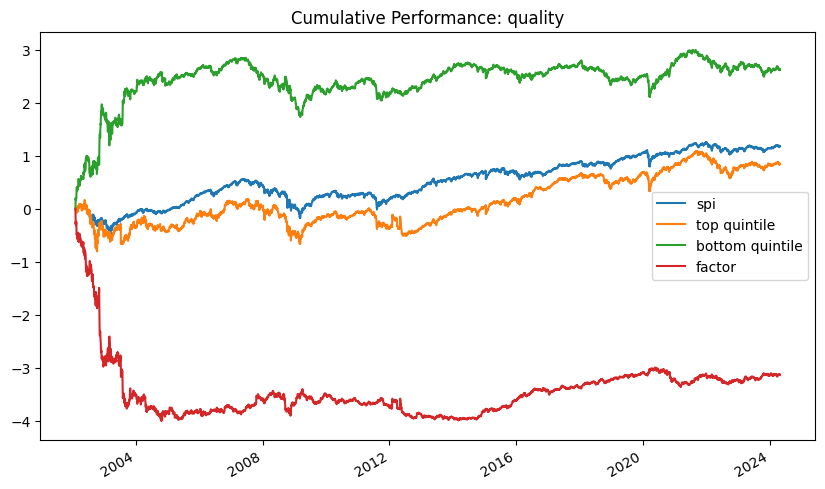

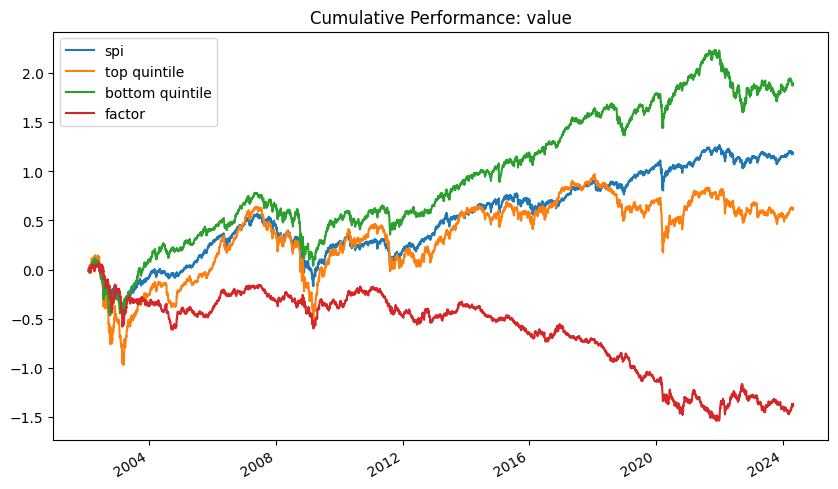

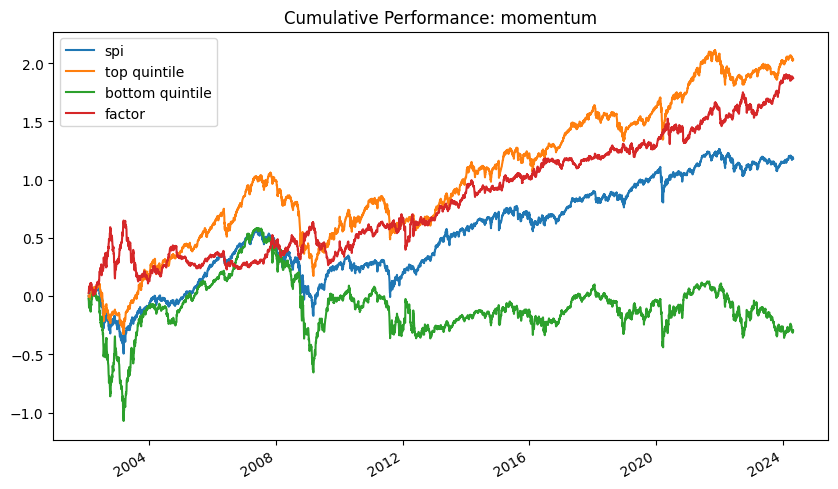

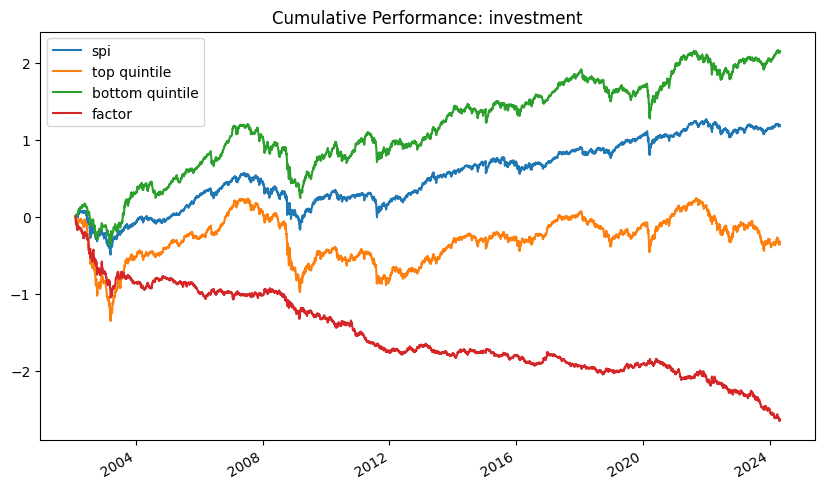

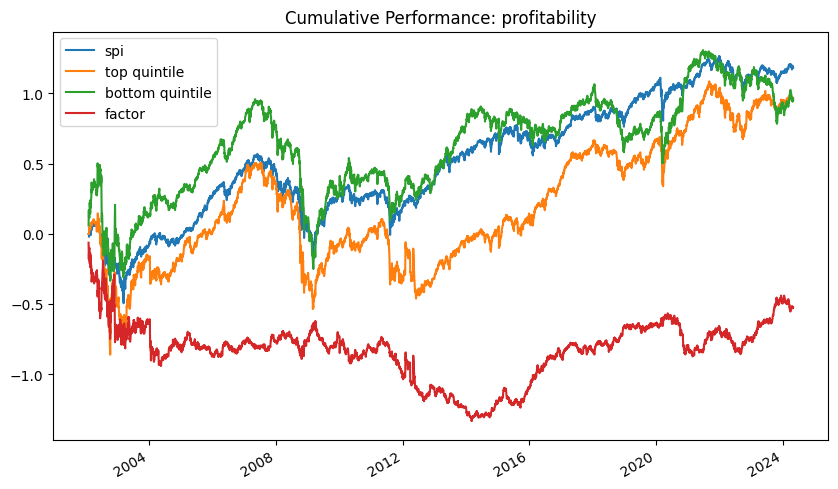

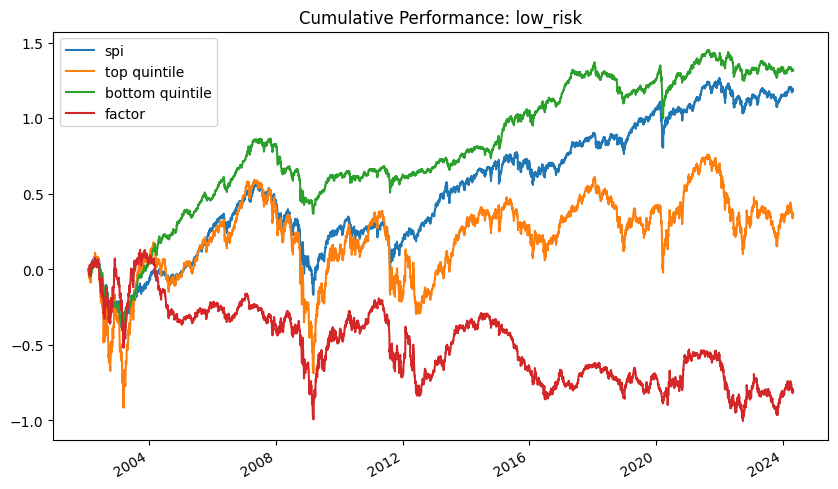

In [7]:
fixed_costs = 0
variable_costs = 0
return_series = data.get_return_series()

factor_results = {}
top_quintile_returns = {}
bottom_quintile_returns = {}
factor_returns = {}

for factor_theme, fields in JKP_FIELDS.items():

    print(f"Running factor theme: {factor_theme}")

    selection_item_builders = {
        'min_volume': SelectionItemBuilder(
            bibfn=bibfn_selection_min_volume,
            width=365,
            min_volume=500_000,
            agg_fn=np.median,
        ),
        'jkp_data_scores': SelectionItemBuilder(
            bibfn=bibfn_selection_jkp_data_scores,
            fields=fields,
        ),
    }

    optimization_item_builders = {
        'scores': OptimizationItemBuilder(
            bibfn=bibfn_scores,
            fields=fields,
        ),
    }

    bs = BacktestService(
        data=data,
        selection_item_builders=selection_item_builders,
        optimization_item_builders=optimization_item_builders,
        rebdates=rebdates,
        quiet=True,
    )

    # Top quintile portfolio
    bs.optimization = PercentilePortfolio(
        percentile=80,
        sign='>=',
    )

    bt_tqp = Backtest()
    bt_tqp.run(bs=bs)

    # Bottom quintile portfolio
    bs.optimization = PercentilePortfolio(
        percentile=20,
        sign='<=',
    )

    bt_bqp = Backtest()
    bt_bqp.run(bs=bs)

    # Simulate return streams
    sim_tqp = bt_tqp.strategy.simulate(
        return_series=return_series,
        fc=fixed_costs,
        vc=variable_costs,
    )

    sim_bqp = bt_bqp.strategy.simulate(
        return_series=return_series,
        fc=fixed_costs,
        vc=variable_costs,
    )

    sim_factor = sim_tqp - sim_bqp

    factor_results[factor_theme] = {
        'top_quintile_backtest': bt_tqp,
        'bottom_quintile_backtest': bt_bqp,
        'top_quintile_returns': sim_tqp,
        'bottom_quintile_returns': sim_bqp,
        'factor_returns': sim_factor,
    }

    top_quintile_returns[factor_theme] = sim_tqp
    bottom_quintile_returns[factor_theme] = sim_bqp
    factor_returns[factor_theme] = sim_factor

    sim = pd.concat({
        'spi': data.bm_series,
        'top quintile': sim_tqp,
        'bottom quintile': sim_bqp,
        'factor': sim_factor,
    }, axis=1).dropna()

    np.log((1 + sim)).cumsum().plot(
        title=f'Cumulative Performance: {factor_theme}',
        figsize=(10, 6),
    )

## 1. c) Factor analysis

- First, compute a factor-mix return series by averaging the returns of the top-quintile portfolio simulations that you have computed above. 

- Second, run an ordinary least squares regression of y on X, where y is your factor-mix series and X contains i) a constant, ii) the SPI return series, and iii) the factor return series computed in 1.b).

- Use monthly returns.

- Print a summary table of the regression output

**(5 points)**

In [8]:
# Factor-mix return series: average of all top-quintile portfolio return series
factor_mix_returns = pd.concat(top_quintile_returns, axis=1).mean(axis=1)

# Combine dependent variable, SPI, and factor return series
regression_data = pd.concat(
    {
        'factor_mix': factor_mix_returns,
        'spi': data.bm_series,
        **factor_returns,
    },
    axis=1,
).dropna()

# Convert daily returns to monthly returns
regression_data_monthly = regression_data.resample('ME').apply(
    lambda x: (1 + x).prod() - 1
).dropna()

# Define dependent and independent variables
y = regression_data_monthly['factor_mix']
X = regression_data_monthly.drop(columns='factor_mix')

# Add constant
X = sm.add_constant(X)

# Run OLS regression
model = sm.OLS(y, X)
results = model.fit()

# Print regression summary
print(results.summary())

C:\Users\marce\AppData\Local\Temp\ipykernel_31804\2911413334.py:5: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  regression_data = pd.concat(


                            OLS Regression Results                            
Dep. Variable:             factor_mix   R-squared:                       0.867
Model:                            OLS   Adj. R-squared:                  0.863
Method:                 Least Squares   F-statistic:                     241.2
Date:                Wed, 06 May 2026   Prob (F-statistic):          1.45e-109
Time:                        19:31:52   Log-Likelihood:                 651.92
No. Observations:                 267   AIC:                            -1288.
Df Residuals:                     259   BIC:                            -1259.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const             0.0023      0.001      1.685